In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("NYC.csv")

loc_df = df[["pickup_longitude", "pickup_latitude"]].dropna().copy()
loc_df.columns = ["longitude", "latitude"]

loc_df = loc_df[
    (loc_df["longitude"] > -74.1) & (loc_df["longitude"] < -73.7) &
    (loc_df["latitude"] > 40.5) & (loc_df["latitude"] < 40.9)
].copy()

loc_df = loc_df.sample(n=50, random_state=42).reset_index(drop=True)
loc_df["demand"] = np.random.randint(1, 5, size=len(loc_df))

loc_df.head()

,longitude,latitude,demand
0,-73.973473,40.782841,2
1,-73.976532,40.739571,1
2,-73.983688,40.764511,4
3,-73.977768,40.763756,4
4,-74.003899,40.747940,2


In [2]:
depot = pd.DataFrame({
    "longitude": [loc_df["longitude"].mean()],
    "latitude": [loc_df["latitude"].mean()],
    "demand": [0]
})

delivery_df = pd.concat([depot, loc_df], ignore_index=True)
print(delivery_df.shape)
delivery_df.head()

(51, 3)


,longitude,latitude,demand
0,-73.956416,40.748652,0
1,-73.973473,40.782841,2
2,-73.976532,40.739571,1
3,-73.983688,40.764511,4
4,-73.977768,40.763756,4


In [3]:
from math import radians, sin, cos, sqrt, atan2
import numpy as np

def haversine(lon1, lat1, lon2, lat2):
    R = 6371
    lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = sin(dlat / 2)**2 + cos(lat1) * cos(lat2) * sin(dlon / 2)**2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))
    return R * c

coords = delivery_df[["longitude", "latitude"]].values
distance_matrix = np.zeros((len(coords), len(coords)))

for i in range(len(coords)):
    for j in range(len(coords)):
        distance_matrix[i][j] = haversine(
            coords[i][0], coords[i][1],
            coords[j][0], coords[j][1]
        )

distance_matrix[:5, :5]

array([[0.        , 4.06390783, 1.97269539, 2.89590339, 2.46065741],
       [4.06390783, 0.        , 4.81831157, 2.21226497, 2.15275131],
       [1.97269539, 4.81831157, 0.        , 2.83801614, 2.69128391],
       [2.89590339, 2.21226497, 2.83801614, 0.        , 0.50563773],
       [2.46065741, 2.15275131, 2.69128391, 0.50563773, 0.        ]])

In [4]:
from ortools.constraint_solver import pywrapcp, routing_enums_pb2

def create_data_model():
    data = {}
    data["distance_matrix"] = (distance_matrix * 1000).astype(int).tolist()
    data["demands"] = delivery_df["demand"].tolist()
    data["vehicle_capacities"] = [50, 50, 50]
    data["num_vehicles"] = 3
    data["depot"] = 0
    return data

data = create_data_model()
print("Customers including depot:", len(data["distance_matrix"]))
print("Total demand:", sum(data["demands"]))

Customers including depot: 51
Total demand: 121


In [5]:
manager = pywrapcp.RoutingIndexManager(
    len(data["distance_matrix"]),
    data["num_vehicles"],
    data["depot"]
)

routing = pywrapcp.RoutingModel(manager)

In [6]:
def distance_callback(from_index, to_index):
    from_node = manager.IndexToNode(from_index)
    to_node = manager.IndexToNode(to_index)
    return data["distance_matrix"][from_node][to_node]

transit_callback_index = routing.RegisterTransitCallback(distance_callback)
routing.SetArcCostEvaluatorOfAllVehicles(transit_callback_index)

In [7]:
def demand_callback(from_index):
    from_node = manager.IndexToNode(from_index)
    return data["demands"][from_node]

demand_callback_index = routing.RegisterUnaryTransitCallback(demand_callback)

routing.AddDimensionWithVehicleCapacity(
    demand_callback_index,
    0,
    data["vehicle_capacities"],
    True,
    "Capacity"
)

True

In [8]:
search_parameters = pywrapcp.DefaultRoutingSearchParameters()
search_parameters.first_solution_strategy = routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC

# ADD THIS LINE
search_parameters.time_limit.seconds = 5

solution = routing.SolveWithParameters(search_parameters)
print("Solved:", solution is not None)

Solved: True


In [9]:
print("Total demand:", sum(data["demands"]))
print("Total capacity:", sum(data["vehicle_capacities"]))

Total demand: 121
Total capacity: 150


In [10]:
search_parameters = pywrapcp.DefaultRoutingSearchParameters()
search_parameters.first_solution_strategy = routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC

# ADD THIS LINE
search_parameters.time_limit.seconds = 5

solution = routing.SolveWithParameters(search_parameters)
print("Solved:", solution is not None)

Solved: True


In [11]:
def print_solution(data, manager, routing, solution):
    total_distance = 0
    total_load = 0

    for vehicle_id in range(data["num_vehicles"]):
        index = routing.Start(vehicle_id)
        route_distance = 0
        route_load = 0
        route_nodes = []

        while not routing.IsEnd(index):
            node_index = manager.IndexToNode(index)
            route_load += data["demands"][node_index]
            route_nodes.append(node_index)
            previous_index = index
            index = solution.Value(routing.NextVar(index))
            route_distance += routing.GetArcCostForVehicle(previous_index, index, vehicle_id)

        route_nodes.append(manager.IndexToNode(index))

        print(f"Vehicle {vehicle_id}")
        print("Route:", route_nodes)
        print("Load:", route_load)
        print("Distance:", round(route_distance / 1000, 2), "km")
        print("-" * 40)

        total_distance += route_distance
        total_load += route_load

    print("Total distance:", round(total_distance / 1000, 2), "km")
    print("Total load:", total_load)

if solution:
    print_solution(data, manager, routing, solution)

Vehicle 0
Route: [0, 2, 35, 23, 42, 39, 36, 18, 34, 37, 47, 31, 49, 8, 0]
Load: 27
Distance: 53.12 km
----------------------------------------
Vehicle 1
Route: [0, 30, 50, 27, 20, 33, 14, 6, 17, 48, 25, 16, 1, 24, 12, 21, 9, 22, 40, 0]
Load: 48
Distance: 16.46 km
----------------------------------------
Vehicle 2
Route: [0, 44, 10, 13, 29, 28, 7, 5, 46, 41, 43, 15, 3, 4, 45, 38, 26, 11, 19, 32, 0]
Load: 46
Distance: 11.12 km
----------------------------------------
Total distance: 80.7 km
Total load: 121


In [12]:
from math import radians, sin, cos, sqrt, atan2
import numpy as np

def haversine(lon1, lat1, lon2, lat2):
    R = 6371
    lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = sin(dlat / 2)**2 + cos(lat1) * cos(lat2) * sin(dlon / 2)**2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))
    return R * c

def route_distance(route, df):
    total = 0
    for i in range(len(route) - 1):
        a = df.loc[route[i], ["longitude", "latitude"]]
        b = df.loc[route[i + 1], ["longitude", "latitude"]]
        total += haversine(a["longitude"], a["latitude"], b["longitude"], b["latitude"])
    return total

# customer nodes excluding depot
customers = list(range(1, len(delivery_df)))

# split into 3 simple groups
groups = np.array_split(customers, 3)

baseline_total = 0

for i, group in enumerate(groups):
    route = [0] + list(group) + [0]
    dist = route_distance(route, delivery_df)
    baseline_total += dist
    print(f"Baseline vehicle {i}: {round(dist, 2)} km")

print("Baseline total distance:", round(baseline_total, 2), "km")

Baseline vehicle 0: 67.07 km
Baseline vehicle 1: 126.09 km
Baseline vehicle 2: 155.79 km
Baseline total distance: 348.95 km


In [13]:
optimized_distance = 80.7  # your current result
improvement = ((baseline_total - optimized_distance) / baseline_total) * 100

print("Optimized total distance:", round(optimized_distance, 2), "km")
print("Baseline total distance:", round(baseline_total, 2), "km")
print("Distance reduction:", round(improvement, 2), "%")

Optimized total distance: 80.7 km
Baseline total distance: 348.95 km
Distance reduction: 76.87 %


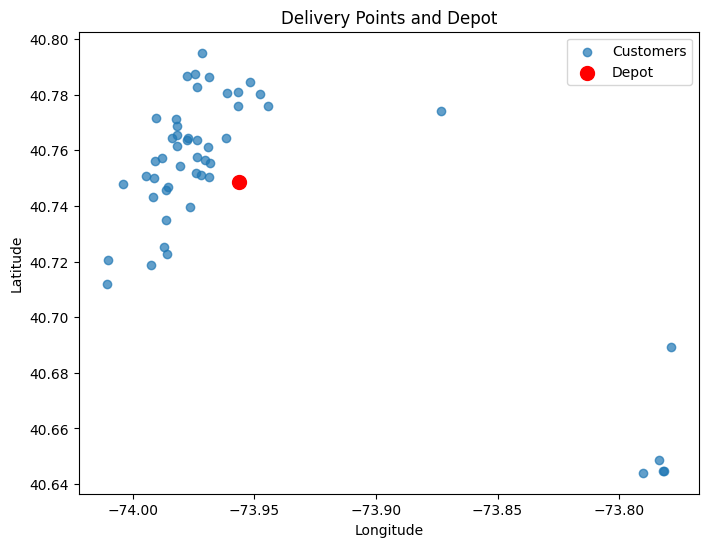

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(delivery_df["longitude"][1:], delivery_df["latitude"][1:], alpha=0.7, label="Customers")
plt.scatter(delivery_df["longitude"][0], delivery_df["latitude"][0], color="red", s=100, label="Depot")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Delivery Points and Depot")
plt.legend()
plt.show()